## LightGBM

### Loading data for local training

In [2]:
import os
from pathlib import Path
import pandas as pd
import numpy as np

# Locate data directory
PROJECT_ROOT = Path("..").resolve() if Path(".").resolve().name == "notebooks" else Path(".").resolve()
EXTERNAL_DATA_DIR = PROJECT_ROOT / "data" / "external"

def sparse_to_dense(indices_col, values_col, size_col, prefix):
    """Expand Spark ML vector columns into separate binary columns"""
    size = int(size_col.iloc[0])
    n = len(indices_col)
    dense_matrix = np.zeros((n, size), dtype=np.float32)
    for row_idx, (idx_arr, val_arr) in enumerate(zip(indices_col, values_col)):
        if idx_arr is not None and len(idx_arr) > 0:
            for i, idx in enumerate(idx_arr):
                if idx is not None:
                    val = 1.0
                    if val_arr is not None and i < len(val_arr) and val_arr[i] is not None:
                        val = float(val_arr[i])
                    dense_matrix[row_idx, int(idx)] = val
    return pd.DataFrame(dense_matrix, columns=[f"{prefix}_{i}" for i in range(size)])

def load_and_preprocess_split(split_name):
    folder = EXTERNAL_DATA_DIR / split_name
    parquets = list(folder.glob("*.parquet"))
    if not parquets:
        raise FileNotFoundError(f"No parquet files found in {folder}")
    
    df = pd.concat([pd.read_parquet(p, engine="fastparquet") for p in parquets], ignore_index=True)
    
    extra_dfs = []
    vector_cols_to_drop = []
    for prefix in ["customer_state_encoded", "primary_product_category_encoded"]:
        if f"{prefix}.indices" in df.columns:
            clean_name = "customer_state" if "customer_state" in prefix else "product_category"
            expanded = sparse_to_dense(df[f"{prefix}.indices"], df[f"{prefix}.values"], df[f"{prefix}.size"], clean_name)
            extra_dfs.append(expanded)
            vector_cols_to_drop.extend([f"{prefix}.type", f"{prefix}.size", f"{prefix}.indices", f"{prefix}.values"])
            
    exclude = ["order_id", "late_delivery_flag_indexed"] + vector_cols_to_drop
    feature_cols = [c for c in df.columns if c not in exclude]
    
    X = df[feature_cols].copy()
    if extra_dfs:
        X = pd.concat([X] + extra_dfs, axis=1)
        
    y = df["late_delivery_flag_indexed"].values.astype(int) if "late_delivery_flag_indexed" in df.columns else None
    return X, y

print("Loading datasets from data/external/...")
X_train, y_train = load_and_preprocess_split("train")
X_val, y_val = load_and_preprocess_split("val")
X_test, y_test = load_and_preprocess_split("test")

print(f"✓ Training set:   {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"✓ Validation set: {X_val.shape[0]} samples, {X_val.shape[1]} features")
print(f"✓ Testing set:    {X_test.shape[0]} samples, {X_test.shape[1]} features")

Loading datasets from data/external/...
✓ Training set:   64238 samples, 138 features
✓ Validation set: 13579 samples, 138 features
✓ Testing set:    12141 samples, 138 features


### Mlflow Setup

In [3]:
import mlflow

# Mlflow setup dynamically
mlflow.set_tracking_uri("databricks")
experiment_name = "/Users/prajwalparajuli2017@gmail.com/revenue_operations/delivery_risk"
mlflow.set_experiment(experiment_name)

print(f"Using experiment : {experiment_name}")

Using experiment : /Users/prajwalparajuli2017@gmail.com/revenue_operations/delivery_risk


If you are using MLflow Tracing, you can migrate your traces to Unity Catalog for unlimited storage, fine-grained access controls, and queryability from notebooks, SQL, and dashboards. Learn more: https://docs.databricks.com/aws/en/mlflow3/genai/tracing/migrate-traces-to-uc


### LightGBM Setup

Fitting 5 folds for each of 60 candidates, totalling 300 fits


2026/08/25 15:33:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
c:\Users\prajw\Desktop\Projects\revenue_operations\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
c:\Users\prajw\Desktop\Projects\revenue_operations\.venv\Lib\site-packages\mlflow\types\utils.py:440: User

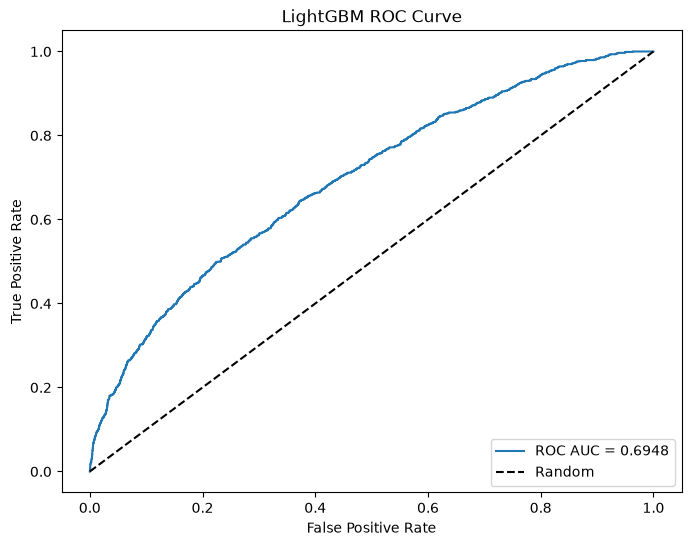

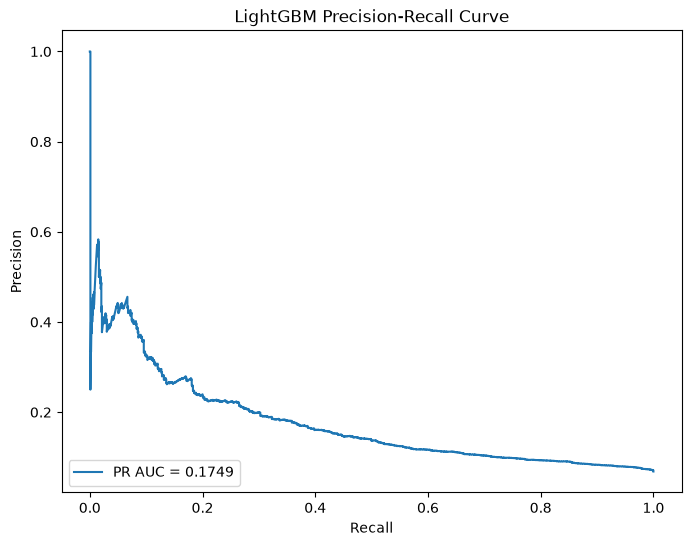


LightGBM Results
Run ID: 638ae3cc6d244e6f86e582bacc250202

Metrics:
  Accuracy:           0.7576
  Precision (Late):   0.1402
  Recall (Late):      0.4952
  F1 Score (Late):    0.2185
  ROC-AUC:            0.6948
  PR-AUC:             0.1749
  Top 10% Capture:    29.1%
    → Found 270 late orders in top 1,357 highest-risk orders
    → Out of 929 total late orders in validation set

Classification Report:
              precision    recall  f1-score   support

     On-time       0.95      0.78      0.86     12650
        Late       0.14      0.50      0.22       929

    accuracy                           0.76     13579
   macro avg       0.55      0.64      0.54     13579
weighted avg       0.90      0.76      0.81     13579



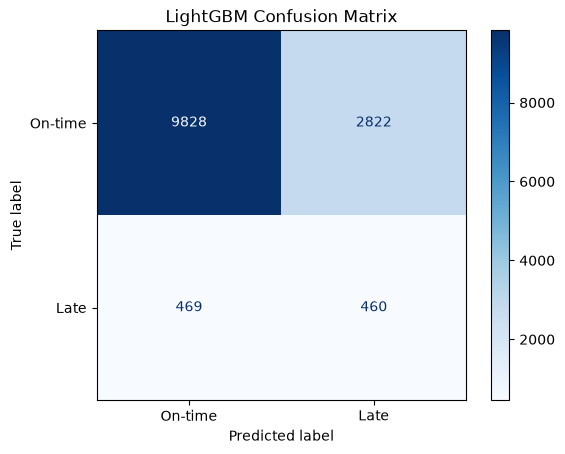

🏃 View run lightgbm_with_tuning at: https://dbc-62bd6a57-4eff.cloud.databricks.com/ml/experiments/4108718011414062/runs/638ae3cc6d244e6f86e582bacc250202
🧪 View experiment at: https://dbc-62bd6a57-4eff.cloud.databricks.com/ml/experiments/4108718011414062

 Results saved to Mlflow experiment: /Users/prajwalparajuli2017@gmail.com/revenue_operations/delivery_risk
View in Mlflow UI


: 

In [ ]:
import lightgbm as lgb
import matplotlib.pyplot as plt
from scipy.stats import randint, uniform, loguniform
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve, auc, 
    ConfusionMatrixDisplay, classification_report
)
import mlflow.lightgbm

# Hyperparameter distribution
param_distribution = {
    "n_estimators" : randint(50, 500),
    "learning_rate" : loguniform(1e-3, 3e-1),
    "num_leaves" : randint(15, 127),
    "max_depth" : randint(3, 10),
    "min_child_samples": randint(10, 100),
    "reg_alpha" : loguniform(1e-8, 10.0),
    "reg_lambda" : loguniform(1e-8, 10.0),
    "subsample" : uniform(0.5, 0.5),
    "colsample_bytree" : uniform(0.4, 0.6)
}

# Create the model
base_lgb = lgb.LGBMClassifier(
    objective = "binary",
    metric = "auc",
    is_unbalance = True,
    random_state = 42,
    verbose = -1
)

# Set up random search with 5 fold CV and 60 iterations
random_search = RandomizedSearchCV(
    estimator = base_lgb,
    param_distributions = param_distribution,
    n_iter = 60,
    random_state = 42,
    cv = 5,
    scoring = "roc_auc",
    n_jobs = -1,
    verbose = 1
)

with mlflow.start_run(run_name = "lightgbm_with_tuning"):

    # Fit random search
    random_search.fit(X_train, y_train)

    # Get the best results
    best_model = random_search.best_estimator_
    best_params = random_search.best_params_

    # Log best parameters to mlflow
    mlflow.log_params(best_params)
    mlflow.log_param("model_type", "lightgbm")

    # Make prediction on validation set
    y_train_pred = best_model.predict(X_train)
    y_pred = best_model.predict(X_val)
    y_pred_proba = best_model.predict_proba(X_val)[:, 1]

    # Calculate training metrics
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_precision = precision_score(y_train, y_train_pred)
    train_recall = recall_score(y_train, y_train_pred)
    train_f1 = f1_score(y_train, y_train_pred)

    # Calculate Validation metrics
    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred, pos_label=1.0)
    recall = recall_score(y_val, y_pred, pos_label=1.0)
    f1 = f1_score(y_val, y_pred, pos_label=1.0)
    roc_auc = roc_auc_score(y_val, y_pred_proba)

    # Calculate PR curve
    precision_curve, recall_curve, pr_threshold = precision_recall_curve(y_val, y_pred_proba, pos_label=1.0)
    pr_auc = auc(recall_curve, precision_curve)

    # Business Metric Top 10% Late Order Capture
    sorted_indeces = np.argsort(-y_pred_proba)
    top_10_pct_count = int(len(y_val) * 0.1)
    top_10_pct_indeces = sorted_indeces[:top_10_pct_count]

    # How many actual late orders are in the top 10%?
    late_orders_in_top_10 = (y_val[top_10_pct_indeces] == 1.0).sum()
    total_late_orders = (y_val == 1).sum()
    capture_rate_10 = late_orders_in_top_10 / total_late_orders

        # Log to Mlflow with "train_" prefix
    mlflow.log_metric("train_accuracy", train_accuracy)
    mlflow.log_metric("train_precision_late", train_precision)
    mlflow.log_metric("train_recall_late", train_recall)
    mlflow.log_metric("train_f1_late", train_f1)

    # Log to Mlflow with "test_" prefix
    mlflow.log_metric("val_accuracy", accuracy)
    mlflow.log_metric("val_precision_late", precision)
    mlflow.log_metric("val_recall_late", recall)
    mlflow.log_metric("val_f1_late", f1)
    mlflow.log_metric("val_roc_auc", roc_auc)
    mlflow.log_metric("val_pr_auc", pr_auc)
    mlflow.log_metric("val_top10pct_capture", capture_rate_10)

    # Log model
    mlflow.lightgbm.log_model(
        best_model, "model",
        input_example = X_train.iloc[:5]
    )

    # Log Confusion matrix as artifact
    fig, ax = plt.subplots(figsize = (8,6))
    ConfusionMatrixDisplay.from_predictions(
        y_val, y_pred, 
        display_labels= ["On time", "Late"],
        cmap = "Blues",
        values_format = 'd',
        ax = ax
    )
    plt.title("LightGBM Confusion Matrix")
    mlflow.log_figure(fig, "confusion_matrix_lightgbm.png")
    plt.close()

     # Generate ROC curve plot
    fpr, tpr, threshold = roc_curve(y_val, y_pred_proba, pos_label = 1.0)
    fig, ax = plt.subplots(figsize = (8,6))
    ax.plot(fpr, tpr, label = f'ROC AUC = {roc_auc:.4f}')
    ax.plot([0,1],[0,1], 'k--', label = "Random")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("LightGBM ROC Curve")
    ax.legend(loc = "lower right")
    mlflow.log_figure(fig, "roc_curve_lightgbm.png")
    plt.show()
    plt.close()

    # Generate PR curve plot
    fig, ax = plt.subplots(figsize = (8,6))
    ax.plot(recall_curve, precision_curve, label = f'PR AUC = {pr_auc:.4f}')
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title("LightGBM Precision-Recall Curve")
    ax.legend(loc = "lower left")
    mlflow.log_figure(fig, "pr_curve_lightgbm.png")
    plt.show()
    plt.close()

    # Get run info
    active_run = mlflow.active_run()
    run_id = active_run.info.run_id if active_run else "unknown"
    
    # Display results
    print("\n" + "="*40)
    print("LightGBM Results")
    print("="*40)
    print(f"Run ID: {run_id}")
    print(f"\nMetrics:")
    print(f"  Accuracy:           {accuracy:.4f}")
    print(f"  Precision (Late):   {precision:.4f}")
    print(f"  Recall (Late):      {recall:.4f}")
    print(f"  F1 Score (Late):    {f1:.4f}")
    print(f"  ROC-AUC:            {roc_auc:.4f}")
    print(f"  PR-AUC:             {pr_auc:.4f}")
    print(f"  Top 10% Capture:    {capture_rate_10:.1%}")
    print(f"    → Found {late_orders_in_top_10} late orders in top {top_10_pct_count:,} highest-risk orders")
    print(f"    → Out of {total_late_orders} total late orders in validation set")
    print("\nClassification Report:")
    print(classification_report(y_val, y_pred, target_names=["On-time", "Late"]))
    print("="*50)

    # Display confusion matrix with plain integer format
    ConfusionMatrixDisplay.from_predictions(
        y_val, y_pred,
        display_labels = ["On-time", "Late"],
        cmap = "Blues",
        values_format = 'd'
    )
    plt.title("LightGBM Confusion Matrix")
    plt.show()

print(f"\n Results saved to Mlflow experiment: {experiment_name}")
print(f"View in Mlflow UI")





### Model Performance Comparison

Comparison of baseline, logistic regression, XGBoost, and LightGBM models on validation set (13,579 orders, 6.8% late delivery rate):

| Metric | Baseline | Logistic Regression | XGBoost | LightGBM |
|---|---|---|---|---|
| Accuracy | 0.9316 | 0.6173 | 0.7328 | 0.7295 |
| Precision (Late) | 0.0000 | 0.1261 | 0.1348 | 0.1321 |
| Recall (Late) | 0.0000 | 0.7750 | 0.5361 | 0.5425 |
| F1 Score (Late) | 0.0000 | 0.2170 | 0.2155 | 0.2125 |
| ROC-AUC | 0.5000 | 0.7521 | 0.6976 | 0.6958 |
| PR-AUC | 0.0684 | 0.1780 | 0.1811 | 0.1802 |
| Top 10% Capture | 10.1% | 30.2% | 29.7% | 29.4% |

**Key Findings:**

* LightGBM performs similarly to XGBoost across all metrics (ROC-AUC 0.6958, PR-AUC 0.1802, Recall 54.3%) while training roughly 3x faster per iteration.
* Captures 29.4% of all late deliveries in the top 10% risk decile (273 out of 929 late orders).
* Leaf-wise growth produces competitive decision boundaries on continuous numerical features, but gradient boosted trees remain capped around ~0.70 ROC-AUC due to feature fragmentation across 100 sparse category columns.

**Next Model:** CatBoost (Categorical Boosting)
* **Justification:** CatBoost implements ordered target statistics and symmetric (oblivious) decision trees, which prevent target leakage and handle categorical interactions more effectively than standard gradient boosting frameworks.
